# Corrected record: every paper number checked against its source file

This notebook demonstrates the **evaluation artifact `eval.py`** from the *layered gold-free checks for NL→FOL
faithfulness* project (iteration 5, evaluation 4). The artifact is a CPU-only, no-LLM, $0 **verifier for the
paper's numbers**. Each number that the hypothesis (§0.2–0.3) or the iteration-4 review quotes is a *claim*. A claim holds:

* the **literal** as written (e.g. `0.614`, `[0.493, 0.736]`, `$4.33`),
* a **locator** that says where the number lives in a result file (JSON key, CSV row/column, regex, JSONL count, ledger sum, or an arithmetic expression over those),
* a **paper-section prefix** (and sometimes a paper regex) that finds the same quantity in the paper draft.

The checker reads the value **from the file** and never retypes it. It compares the value to the claim at the claim's own
precision (`|claim − file| ≤ 0.5·10^-d`, where CIs must match on both bounds and signs must agree). Then it greps the paper for
the same quantity and marks it **MATCH / MISMATCH / NOT_IN_PAPER**. The full run checked 244 claims plus 258 transcribed cells (all 244 claims
MATCH their files). It found **15 paper-vs-file mismatches**, for example every §4.2 CI printed narrower than its source, and COMPOUND 0.643 vs 0.282 in the file.

**What this demo runs.** The original code for the claim checker (`src/io_locators.py`, `src/checker.py`), the numbers/mismatch
tables and the review-number mapping from `eval.py`, and the checker **mutation test** (`src/mutation.py`). They run on a
100-item subset: 88 claims + 12 transcription rows. The subset always includes the 15 paper mismatches and the 20 claims the mutation test uses.
The original pipeline reads about 45 result files by absolute path from the research run tree. `mini_demo_data.json` holds
**pruned copies of exactly the cells these 100 items read** (plus the full paper draft and review), keyed by the original
paths, so the unchanged locator code resolves them from memory.
Stages that need the whole run tree are not re-run here: `record_final.md` rendering and its 8 lints, the spend ledger, the claims ledger, the skeleton, figures F1–F4 and the independent audit.
Their full-run results are shown from the bundled `metrics_agg` at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# matplotlib, PyYAML — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0', 'PyYAML==6.0.3')

In [2]:
# --- original eval.py import block ---
import csv
import json
import re
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

from loguru import logger

# --- extra imports used by the original src/ modules (io_locators, checker, mutation) ---
import copy
import hashlib
import io
import math
from typing import Any

# --- notebook additions ---
import yaml
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['claims'])} claims, {len(data['transcriptions'])} transcription rows, "
      f"{len(data['files'])} (pruned) source files bundled")

88 claims, 12 transcription rows, 36 (pruned) source files bundled


## Configuration

`eval.py` has no training-style hyperparameters. Its scale is the **number of items checked**. The original run checked
all 244 claims + 258 transcription rows in ~30 s. The demo data bundles 88 claims + 12 transcriptions, so the values below
check the entire bundled subset. Lower them to check fewer items. The mutation test always uses its 20 fixed claims.

In [5]:
N_CLAIMS = 88            # claims to check from the bundled subset (max 88; original full run: 244)
N_TRANSCRIBED = 12       # transcription rows to check (max 12; original full run: 258)
RUN_MUTATION_TEST = True # original: always run (10 mutated claims must be caught, 10 untouched must MATCH)
WS = Path("demo_out")    # NOTEBOOK: outputs go here (original: the artifact folder itself)

## Logging and output folder (from `eval.py`)

This is the same loguru setup as the original. The script used `WS = Path(__file__).resolve().parent`. The notebook uses the
`WS` folder from the config cell.

In [6]:
WS.mkdir(exist_ok=True)  # NOTEBOOK
(WS / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs/run.log", rotation="30 MB", level="DEBUG")

2

## Source locators (`src/io_locators.py`)

Every number is read through `resolve(loc)`. A locator is a small dict:

| `t` | reads |
|---|---|
| `json` | a dotted key path in a JSON file (keys may contain dots, so the longest prefix wins) |
| `csv` | one cell: the rows matching `where`, column `col` (more than one distinct value → `Ambiguous`) |
| `md` / `regex` | a markdown-table cell or a regex group in a text file |
| `jsonl_count` / `ledger` | a row count or a cost sum over a JSONL file |
| `expr` | arithmetic over other locators (e.g. a ratio of two file values) |
| `const` | context values that have no file (flagged in the note) |

The code below is the original module. The only change is `_read_text`, which reads from `data["files"]` instead of disk.
In the original, the notebook's names were a module imported as `L`. Here the notebook namespace itself plays that role.

In [7]:
"""Loaders that read one value from a source file and return (value, locator_string).

Every number in the corrected record is pulled through one of these functions. A locator
is a small dict (see `resolve`) so it can be stored in claims_spec.yaml and replayed.
Paths are absolute and read-only; every file read is hashed into a registry.
"""

import csv
import hashlib
import io
import json
import re
from pathlib import Path
from typing import Any

RUN = "/ai-inventor/aii_data/runs/run_u75jRHUss0zo/3_invention_loop"
I3 = f"{RUN}/iter_3/gen_art"
I4 = f"{RUN}/iter_4/gen_art"
PAPER = f"{RUN}/iter_4/gen_report_text/gen_report_text/paper_draft.md"
REVIEW = f"{RUN}/iter_4/review_report/review_report/.terminal_claude_agent_struct_out.json"

HASHES: dict[str, str] = {}
_JSON_CACHE: dict[str, Any] = {}
_TEXT_CACHE: dict[str, str] = {}


class NotFound(Exception):
    """The file or the key does not exist."""


class Ambiguous(Exception):
    """More than one candidate cell matched."""


def _read_text(path: str) -> str:
    if path not in _TEXT_CACHE:
        # NOTEBOOK: read from the bundled virtual file store (keyed by the original absolute path)
        # instead of Path(path).read_bytes(); the rest of the module is unchanged.
        if path not in data["files"]:
            raise NotFound(f"source missing: {path}")
        b = data["files"][path].encode("utf-8")
        HASHES[path] = hashlib.sha256(b).hexdigest()
        _TEXT_CACHE[path] = b.decode("utf-8", errors="replace")
    return _TEXT_CACHE[path]




def _load_json(path: str) -> Any:
    if path not in _JSON_CACHE:
        _JSON_CACHE[path] = json.loads(_read_text(path))
    return _JSON_CACHE[path]


def _walk_key(obj: Any, key: str) -> Any:
    """Resolve a dotted key where individual keys may themselves contain dots/spaces.

    At each level the longest prefix of the remaining path that is a key is taken.
    List indices are written as [i] directly after a key or as a bare integer part.
    """
    rest = key
    cur = obj
    while rest:
        m = re.match(r"^\[(\d+)\]\.?", rest)
        if m and isinstance(cur, list):
            cur = cur[int(m.group(1))]
            rest = rest[m.end():]
            continue
        if isinstance(cur, list):
            m = re.match(r"^(\d+)\.?", rest)
            if not m:
                raise NotFound(f"list index expected at '{rest}'")
            cur = cur[int(m.group(1))]
            rest = rest[m.end():]
            continue
        if not isinstance(cur, dict):
            raise NotFound(f"cannot descend into {type(cur).__name__} at '{rest}'")
        hit = None
        for k in sorted(cur.keys(), key=len, reverse=True):
            if rest == k or rest.startswith(k + ".") or rest.startswith(k + "["):
                hit = k
                break
        if hit is None:
            raise NotFound(f"key not found at '{rest[:60]}'")
        cur = cur[hit]
        rest = rest[len(hit):]
        if rest.startswith("."):
            rest = rest[1:]
    return cur


def json_key(path: str, dotted_key: str) -> tuple[Any, str]:
    return _walk_key(_load_json(path), dotted_key), f"{path} :: {dotted_key}"


def _csv_rows(path: str) -> list[dict[str, str]]:
    text = _read_text(path)
    lines = [ln for ln in text.splitlines() if not ln.startswith("# source") and not ln.startswith("#")]
    return list(csv.DictReader(io.StringIO("\n".join(lines))))


def csv_cell(path: str, row_filter: dict[str, str], col: str) -> tuple[Any, str]:
    rows = [r for r in _csv_rows(path) if all(str(r.get(k, "")) == str(v) for k, v in row_filter.items())]
    if not rows:
        raise NotFound(f"no csv row {row_filter} in {path}")
    vals = {r.get(col) for r in rows}
    if len(vals) > 1:
        raise Ambiguous(f"{len(rows)} rows with differing '{col}' for {row_filter}")
    if col not in rows[0]:
        raise NotFound(f"column {col} missing in {path}")
    filt = ", ".join(f"{k}={v}" for k, v in row_filter.items())
    return rows[0][col], f"{path} :: row[{filt}] col[{col}]"


def md_table_cell(path: str, table_heading: str, row_regex: str, col_index: int) -> tuple[Any, str]:
    """Fallback reader for markdown tables (used only when no machine source exists)."""
    text = _read_text(path)
    start = text.find(table_heading)
    if start < 0:
        raise NotFound(f"heading '{table_heading}' not in {path}")
    nxt = re.search(r"\n#{2,3} ", text[start + len(table_heading):])
    block = text[start: start + len(table_heading) + (nxt.start() if nxt else len(text))]
    rows = [ln for ln in block.splitlines() if ln.startswith("|") and re.search(row_regex, ln)]
    if not rows:
        raise NotFound(f"row /{row_regex}/ not in table '{table_heading}'")
    if len(rows) > 1:
        raise Ambiguous(f"{len(rows)} rows match /{row_regex}/")
    cells = [c.strip() for c in rows[0].strip().strip("|").split("|")]
    return cells[col_index], f"{path} :: table '{table_heading}' row /{row_regex}/ col {col_index}"


def regex(path: str, pattern: str, group: int = 1) -> tuple[Any, str]:
    text = _read_text(path)
    ms = list(re.finditer(pattern, text, flags=re.M))
    if not ms:
        raise NotFound(f"/{pattern}/ not in {path}")
    vals = {m.group(group) for m in ms}
    if len(vals) > 1:
        raise Ambiguous(f"/{pattern}/ matched {len(ms)} differing values")
    return ms[0].group(group), f"{path} :: regex /{pattern}/ group {group}"


def jsonl_count(path: str, where: dict[str, Any]) -> tuple[int, str]:
    text = _read_text(path)
    n = 0
    for ln in text.splitlines():
        if not ln.strip():
            continue
        r = json.loads(ln)
        if all(r.get(k) == v for k, v in where.items()):
            n += 1
    return n, f"{path} :: count rows where {where}"


def ledger_sum(path: str, field: str = "cost_usd") -> tuple[float, str]:
    text = _read_text(path)
    s = 0.0
    for ln in text.splitlines():
        if ln.strip():
            try:
                s += float(json.loads(ln).get(field) or 0.0)
            except (json.JSONDecodeError, TypeError, ValueError):
                continue
    return s, f"{path} :: sum({field})"


def to_float(v: Any) -> float:
    if isinstance(v, bool):
        return float(v)
    if isinstance(v, (int, float)):
        return float(v)
    s = str(v).strip().replace("−", "-").replace(",", "").replace("$", "")
    m = re.search(r"-?\d+(?:\.\d+)?(?:e-?\d+)?", s)
    if not m:
        raise ValueError(f"no number in {v!r}")
    return float(m.group(0))


def resolve(loc: dict[str, Any]) -> tuple[Any, str]:
    """Resolve a locator dict to (value, locator_string)."""
    t = loc["t"]
    if t == "json":
        v, s = json_key(loc["f"], loc["k"])
    elif t == "csv":
        v, s = csv_cell(loc["f"], loc["where"], loc["col"])
    elif t == "md":
        v, s = md_table_cell(loc["f"], loc["h"], loc["row"], loc["col"])
    elif t == "regex":
        v, s = regex(loc["f"], loc["pat"], loc.get("g", 1))
    elif t == "jsonl_count":
        v, s = jsonl_count(loc["f"], loc["where"])
    elif t == "ledger":
        v, s = ledger_sum(loc["f"], loc.get("field", "cost_usd"))
    elif t == "expr":
        env = {}
        parts = []
        for name, sub in loc["args"].items():
            val, sloc = resolve(sub)
            env[name] = to_float(val)
            parts.append(f"{name}={sloc}")
        v = eval(loc["expr"], {"__builtins__": {}}, env)  # noqa: S307 - arithmetic on file values only
        s = f"expr[{loc['expr']}] with " + " ; ".join(parts)
    elif t == "const":
        v, s = loc["v"], f"CONTEXT (no file value): {loc.get('why', '')}"
    else:
        raise ValueError(f"unknown locator type {t}")
    if "idx" in loc:
        v = v[loc["idx"]]
        s += f" [{loc['idx']}]"
    return v, s

L = sys.modules[__name__]  # NOTEBOOK: the original imported this module as `L`; here it is the notebook namespace

## The claim checker (`src/checker.py`)

`parse_literal` turns a claim literal into (value, tolerance) at the literal's own precision. Percentages are compared
as fractions and `$`/`,`/`+` are handled. `num_match` also rejects a sign disagreement. `check_claim` then works in three steps:

1. resolves the value (and the CI, from `ciloc` or from an inline `"0.278 [0.239, 0.319]"` cell), then compares it to the claim → `match_hyp_vs_file`;
2. searches the **paper draft** for the same quantity, either by greping the literal inside the named section or with a claim-specific regex `pp` that captures the paper's own number;
3. compares the paper's number to the **file** value → `match_paper_vs_file`.

Transcription rows (`value = None`) have no claim literal. Their file value is read and formatted, with status `TRANSCRIBED`.

In [8]:
"""Claim checker: pull each claim's value from its source file and compare.

Precision rule: MATCH iff |claim - source| <= 0.5 * 10^-d (d = decimals of the claim literal;
percentages are compared as fractions, so '44.9%' has d = 3). A CI matches only if both bounds
match, each at its own precision. Signs must agree. Statuses: MATCH, MISMATCH, NOT_FOUND,
AMBIGUOUS. String claims (verdict labels) must equal the source string exactly.
"""

import math
import re
from pathlib import Path
from typing import Any


NUM_RE = r"[+\-−]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-−]?\d+)?%?"


def norm(s: str) -> str:
    return s.replace("−", "-").replace("−", "-").strip()


def is_numeric_literal(s: str) -> bool:
    return bool(re.fullmatch(r"[+\-]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-]?\d+)?%?", norm(s)))


def parse_literal(s: str) -> tuple[float, float, dict]:
    """Return (value_as_fraction_or_number, tolerance, format_info)."""
    t = norm(s)
    info = {"sign": t.startswith("+"), "pct": t.endswith("%"), "usd": "$" in t, "sci": "e" in t.lower()}
    core = t.replace("$", "").replace(",", "").rstrip("%").lstrip("+")
    if info["sci"]:
        mant, exp = core.lower().split("e")
        dec = len(mant.split(".")[1]) if "." in mant else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec) * 10 ** int(exp)
        info["dec"], info["exp"] = dec, int(exp)
    else:
        dec = len(core.split(".")[1]) if "." in core else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec)
        info["dec"] = dec
    if info["pct"]:
        val /= 100.0
        tol /= 100.0
    info["thousands"] = "," in t
    return val, tol * (1 + 1e-9) + 1e-12, info


def parse_ci(s: str) -> list[str]:
    parts = [p.strip() for p in norm(s).strip("[]").split(",")]
    if len(parts) != 2:
        raise ValueError(f"bad CI literal {s}")
    return parts


def fmt_like(v: float, claim_literal: str) -> str:
    """Format a file value at the claim literal's precision/style (display only)."""
    _, _, info = parse_literal(claim_literal)
    x = v * 100.0 if info["pct"] else v
    if info.get("sci"):
        body = f"{x / 10 ** info['exp']:.{info['dec']}f}e{info['exp']}"
    elif info["thousands"]:
        body = f"{x:,.{info['dec']}f}"
    else:
        body = f"{x:.{info['dec']}f}"
    if body.startswith("-"):
        body = "−" + body[1:]
    elif info["sign"] and x > 0:
        body = "+" + body
    if info["usd"]:
        body = ("−$" + body[1:]) if body.startswith("−") else "$" + body
    return body + ("%" if info["pct"] else "")


def fmt_ci_like(ci: list[float], claim_ci: str) -> str:
    lo_l, hi_l = parse_ci(claim_ci)
    return f"[{fmt_like(ci[0], lo_l)}, {fmt_like(ci[1], hi_l)}]"


def num_match(claim_literal: str, source: float) -> bool:
    val, tol, _ = parse_literal(claim_literal)
    if val != 0 and source != 0 and math.copysign(1, val) != math.copysign(1, source) and abs(source) > tol:
        return False
    return abs(val - source) <= tol


def split_value_ci(v: Any) -> tuple[Any, list[float] | None]:
    """A source cell like '0.278 [0.239, 0.319]' carries its own CI."""
    if isinstance(v, str) and "[" in v:
        m = re.match(r"\s*([^\[]+)\[([^,]+),([^\]]+)\]", v)
        if m:
            return m.group(1).strip(), [L.to_float(m.group(2)), L.to_float(m.group(3))]
    return v, None


def _get_ci(ciloc: Any) -> tuple[list[float], str]:
    if isinstance(ciloc, list):
        (lo, s1), (hi, s2) = L.resolve(ciloc[0]), L.resolve(ciloc[1])
        return [L.to_float(lo), L.to_float(hi)], f"{s1} ; {s2}"
    v, s = L.resolve(ciloc)
    return [L.to_float(v[0]), L.to_float(v[1])], s


# ---------------------------------------------------------------- paper helpers
_PAPER_LINES: list[str] | None = None


def paper_lines() -> list[str]:
    global _PAPER_LINES
    if _PAPER_LINES is None:
        _PAPER_LINES = L._read_text(L.PAPER).splitlines()
    return _PAPER_LINES


def section_range(prefix: str | None) -> tuple[int, int]:
    """1-based inclusive line range of the paper section whose heading starts with prefix."""
    lines = paper_lines()
    if not prefix:
        return 1, len(lines)
    for i, ln in enumerate(lines):
        if ln.startswith(prefix):
            level = len(ln) - len(ln.lstrip("#"))
            for j in range(i + 1, len(lines)):
                m = re.match(r"^(#+) ", lines[j])
                if m and len(m.group(1)) <= level:
                    return i + 1, j
            return i + 1, len(lines)
    return 1, len(lines)


def headings() -> list[tuple[int, str]]:
    return [(i + 1, ln) for i, ln in enumerate(paper_lines()) if re.match(r"^#+ ", ln)]


def literal_variants(lit: str) -> list[str]:
    t = norm(lit)
    out = {t, t.lstrip("+"), t.replace("-", "−"), t.lstrip("+").replace("-", "−")}
    if t.endswith("%"):
        v = float(t.rstrip("%").replace(",", "")) / 100
        out.add(f"{v:.3f}".rstrip("0"))
    return sorted(out, key=len, reverse=True)


def grep_paper(lit: str, prefix: str | None) -> tuple[str | None, int | None]:
    lo, hi = section_range(prefix)
    lines = paper_lines()
    for var in literal_variants(lit):
        pat = r"(?<![\d.])" + re.escape(var) + r"(?![\d])"
        for i in range(lo - 1, hi):
            if re.search(pat, lines[i]):
                return var, i + 1
    return None, None


def paper_pattern(pp: Any, prefix: str | None) -> tuple[str | None, int | None]:
    pat, grp = (pp, 1) if isinstance(pp, str) else pp
    lo, hi = section_range(prefix)
    lines = paper_lines()
    for i in range(lo - 1, hi):
        m = re.search(pat, lines[i])
        if m:
            return m.group(grp), i + 1
    return None, None


# ---------------------------------------------------------------- main check
def check_claim(cl: dict) -> dict:
    row = {k: cl.get(k) for k in ("id", "sec", "text", "value", "ci", "role", "ps")}
    row.update(source_path="", locator="", source_value="", source_ci="", match_hyp_vs_file="", paper_value="",
               paper_line="", match_paper_vs_file="", note="", source_value_raw=None, source_ci_raw=None)
    try:
        v, s = L.resolve(cl["loc"])
        row["locator"] = s
        row["source_path"] = s.split(" :: ")[0] if " :: " in s else s
        v, inline_ci = split_value_ci(v)
        ci_src = None
        if cl.get("ciloc"):
            ci_src, cs = _get_ci(cl["ciloc"])
            row["locator"] += f" || CI: {cs}"
        elif inline_ci is not None:
            ci_src = inline_ci
        if cl["loc"]["t"] == "const":
            row["note"] = "CONTEXT: no file value; " + cl["loc"].get("why", "")
        if cl["value"] is None:  # transcription row: value read by code, no claim literal
            fv = L.to_float(v)
            row["source_value_raw"] = fv
            fmt = cl.get("fmt", "0.000")
            row["source_value"] = (re.sub(r"e([+-])0*(\d)", lambda m: "e" + ("−" if m.group(1) == "-" else "") + m.group(2), f"{fv:.2e}") if fmt == "0.00e0" else fmt_like(fv, fmt))
            ok = True
        elif is_numeric_literal(cl["value"]):
            fv = L.to_float(v)
            row["source_value_raw"] = fv
            row["source_value"] = fmt_like(fv, cl["value"])
            ok = num_match(cl["value"], fv)
        else:
            row["source_value"] = str(v)
            row["source_value_raw"] = str(v)
            ok = str(v) == cl["value"]
        if cl.get("ci") and cl["value"] is None:
            if ci_src is not None:
                row["source_ci_raw"] = ci_src
                row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
        elif cl.get("ci"):
            if ci_src is None:
                if cl["id"] == "t1_vs_s4":  # CI of S4-c, sign-flipped
                    raw, cs = L.resolve({"t": "json", "f": cl["loc"]["args"]["a"]["f"],
                                         "k": cl["loc"]["args"]["a"]["k"][: -len(".delta")] + ".ci"})
                    ci_src = [-L.to_float(raw[1]), -L.to_float(raw[0])]
                    row["locator"] += f" || CI (negated, bounds swapped): {cs}"
                else:
                    row["note"] += " CI not in source;"
            if ci_src is not None:
                row["source_ci_raw"] = ci_src
                row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
                lo_l, hi_l = parse_ci(cl["ci"])
                ok = ok and num_match(lo_l, ci_src[0]) and num_match(hi_l, ci_src[1])
        elif ci_src is not None:
            row["source_ci_raw"] = ci_src
            row["source_ci"] = f"[{ci_src[0]:.3f}, {ci_src[1]:.3f}]".replace("-", "−")
        row["match_hyp_vs_file"] = ("TRANSCRIBED" if cl["value"] is None else ("MATCH" if ok else "MISMATCH"))
    except L.NotFound as e:
        row["match_hyp_vs_file"] = "NOT_FOUND"
        row["note"] += str(e)[:200]
        return row
    except L.Ambiguous as e:
        row["match_hyp_vs_file"] = "AMBIGUOUS"
        row["note"] += str(e)[:200]
        return row
    # paper side
    if cl["value"] is None:
        row["match_paper_vs_file"] = "n/a"
        return row
    if cl.get("pp"):
        pv, line = paper_pattern(cl["pp"], cl.get("ps"))
        if pv is None:
            row["paper_value"], row["match_paper_vs_file"] = "", "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = pv, line
            if pv.startswith("["):
                lo_l, hi_l = parse_ci(pv)
                okp = row["source_ci_raw"] is not None and num_match(lo_l, row["source_ci_raw"][0]) and num_match(hi_l, row["source_ci_raw"][1])
            elif is_numeric_literal(pv) and isinstance(row["source_value_raw"], float):
                okp = num_match(pv, row["source_value_raw"])
            else:
                okp = pv == str(row["source_value_raw"])
            row["match_paper_vs_file"] = "MATCH" if okp else "MISMATCH"
    else:
        var, line = grep_paper(cl["value"], cl.get("ps")) if is_numeric_literal(cl["value"]) else (None, None)
        if var is None:
            row["match_paper_vs_file"] = "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = var, line
            row["match_paper_vs_file"] = row["match_hyp_vs_file"]
    return row


def check_all(claims: list[dict]) -> list[dict]:
    return [check_claim(c) for c in claims]


def write_hashes(path: Path) -> None:
    lines = ["# source: sha256 of every file read by the locators (computed at read time)", "path,sha256"]
    lines += [f"{p},{h}" for p, h in sorted(L.HASHES.items())]
    path.write_text("\n".join(lines) + "\n")

CK = sys.modules[__name__]  # NOTEBOOK: the original imported this module as `CK`

## The claims to check (subset of `src/claims_spec.py` / `src/transcribe.py`)

In the original, `CLAIMS` (244 hand-curated literals + locators) and `T` (258 transcription rows) are built in Python.
Here they come from `mini_demo_data.json`, in the original dict format. Let's look at one claim that the paper misreports:

In [9]:
ALL_CLAIMS = data["claims"]                        # NOTEBOOK: subset of src.claims_spec.CLAIMS
CLAIMS = ALL_CLAIMS[:N_CLAIMS]
TRANSCRIBED = data["transcriptions"][:N_TRANSCRIBED]  # NOTEBOOK: subset of src.transcribe.T
print(json.dumps(next(c for c in ALL_CLAIMS if c["id"] == "x9_csc"), indent=1, ensure_ascii=False))

{
 "id": "x9_csc",
 "sec": "hyp §0.3A T4",
 "text": "c_csc strat AUROC",
 "value": "0.614",
 "ci": "[0.493, 0.736]",
 "loc": {
  "t": "json",
  "f": "analysis.json",
  "k": "b_PRIMARY.metrics.R_AB [strat].c_csc.point"
 },
 "ciloc": {
  "t": "json",
  "f": "analysis.json",
  "k": "b_PRIMARY.metrics.R_AB [strat].c_csc.ci"
 },
 "role": "DEV",
 "ps": "### 4.2",
 "pp": "\\*\\*CSC\\*\\* \\| \\*\\*0\\.614 (\\[[^\\]]+\\])"
}


## `eval.py` helpers: numbers table and review-number mapping

`write_numbers` writes `numbers.csv`: one row per checked number, with the file locator, the source value and CI, and both match
statuses. `review_numbers` extracts every decimal or percentage literal from the 11 review critiques. It checks whether some
checked row (a source value, a source CI bound, or a paper value) accounts for it; otherwise the literal is `UNMAPPED`.
With only 100 of the 502 rows checked, more literals stay UNMAPPED here than in the full run.

In [10]:
NUM_COLS = ["claim_id", "section", "claim_text", "claim_value", "claim_ci", "source_path", "locator", "source_value",
            "source_ci", "match_hyp_vs_file", "paper_value", "paper_line", "match_paper_vs_file", "data_role", "note"]


def write_numbers(rows: list[dict], path: Path) -> None:
    with path.open("w", newline="") as f:
        f.write("# source: every row's value is read by src/io_locators.py from source_path at locator (never typed); "
                "claim_value is the hypothesis/review literal; statuses per src/checker.py precision rule\n")
        w = csv.writer(f)
        w.writerow(NUM_COLS)
        for r in rows:
            w.writerow([r["id"], r.get("sec"), r.get("text"), r.get("value") or "", r.get("ci") or "", r.get("source_path"),
                        r.get("locator"), r.get("source_value"), r.get("source_ci"), r.get("match_hyp_vs_file"),
                        r.get("paper_value"), r.get("paper_line"), r.get("match_paper_vs_file"), r.get("role"), r.get("note")])


def review_numbers(rows: list[dict]) -> list[dict]:
    """(ii) every number named in the 11 critiques -> covered by a numbers.csv row or UNMAPPED."""
    rv = json.loads(L._read_text(L.REVIEW))
    vals = []
    for r in rows:
        for key in ("source_value_raw",):
            v = r.get(key)
            if isinstance(v, float):
                vals.append((v, r["id"]))
        ci = r.get("source_ci_raw")
        if ci:
            vals += [(ci[0], r["id"]), (ci[1], r["id"])]
        pv = r.get("paper_value")
        if pv and str(pv).startswith("["):
            try:
                for b in CK.parse_ci(str(pv)):
                    vals.append((CK.parse_literal(b)[0], r["id"] + "(paper CI)"))
            except ValueError:
                pass
        if pv and re.fullmatch(r"[+\-−]?\$?\d[\d.,]*%?", str(pv)):
            try:
                vals.append((CK.parse_literal(str(pv))[0], r["id"] + "(paper)"))
            except ValueError:
                pass
    out = []
    for k, cr in enumerate(rv["critiques"], 1):
        text = cr["description"] + " " + cr["suggested_action"]
        for m in re.finditer(r"(?<![\w.])[+\-−]?\$?\d+(?:\.\d+)?%?(?![\w])", text):
            lit = m.group(0)
            pre = text[max(0, m.start() - 8): m.start()]
            if re.search(r"(§|§\d(?:\.\d)?[–-]|arXiv |\()$", pre) or re.fullmatch(r"\d{4}\.\d{5}", lit):
                continue  # section numbers and arXiv ids are not measurements
            if not re.search(r"\.\d|%", lit):
                continue  # integers (section numbers, counts) are not checked here
            try:
                val, tol, _ = CK.parse_literal(lit)
            except ValueError:
                continue
            hits = sorted({rid for v, rid in vals if abs(abs(v) - abs(val)) <= tol})
            out.append(dict(critique=k, literal=lit, context=text[max(0, m.start() - 50): m.end() + 30].replace("\n", " "),
                            covered_by=";".join(hits[:5]), status="MAPPED" if hits else "UNMAPPED"))
    return out

## Step 1–2 of `main()`: export the claim spec, check every claim and transcription row

This is the start of the original `main()`, unchanged apart from dedenting: it exports `claims_spec.yaml`, runs `check_all`, and logs the
status counts. In the full run, all 244 claims MATCH their source files. The paper-vs-file column gave 153 MATCH / 15 MISMATCH / 76 not in the paper.

In [11]:
t0 = time.time()
# NOTEBOOK: the original also asserted "requests" not in sys.modules; Colab preloads requests itself
assert "openai" not in sys.modules
import yaml
(WS / "claims_spec.yaml").write_text("# hand-curated claim list: literal as written in hypothesis §0.2-0.3 / review + one locator each (values are pulled by code)\n"
                                     + yaml.safe_dump({"claims": CLAIMS, "transcriptions": TRANSCRIBED}, allow_unicode=True, sort_keys=False, width=200))
logger.info(f"checking {len(CLAIMS)} claims + {len(TRANSCRIBED)} transcription rows")
rows = CK.check_all(CLAIMS) + CK.check_all(TRANSCRIBED)
cnt = Counter(r["match_hyp_vs_file"] for r in rows)
logger.info(f"hyp-vs-file: {dict(cnt)}; paper-vs-file: {dict(Counter(r['match_paper_vs_file'] for r in rows))}")
bad = [r for r in rows if r["match_hyp_vs_file"] in ("NOT_FOUND", "AMBIGUOUS")]
for r in bad:
    logger.warning(f"{r['id']}: {r['match_hyp_vs_file']} {r['note'][:160]}")

13:28:29|INFO   |checking 88 claims + 12 transcription rows


13:28:30|INFO   |hyp-vs-file: {'MATCH': 88, 'TRANSCRIBED': 12}; paper-vs-file: {'MATCH': 52, 'NOT_IN_PAPER': 21, 'MISMATCH': 15, 'n/a': 12}


## Numbers table, mismatches and review-number mapping

The next part of the original `main()` (the spend ledger, then `record_final.md` via `src.sections.build` and the 8 lints) needs the
whole research run tree, so it is not re-run here. The original wrote `numbers.csv` and `mismatches.csv` from `ctx.rows` (the checked rows
plus computed rows added while rendering). The demo writes them from the checked `rows`. The review-number mapping below uses the original code.

In [12]:
(WS / "tables").mkdir(exist_ok=True)  # NOTEBOOK
write_numbers(rows, WS / "numbers.csv")  # original: ctx.rows
mism = [r for r in rows if r.get("match_hyp_vs_file") in ("MISMATCH", "NOT_FOUND", "AMBIGUOUS") or r.get("match_paper_vs_file") == "MISMATCH"]
write_numbers(mism, WS / "mismatches.csv")
rn = review_numbers(rows)  # original: ctx.rows
with (WS / "tables/review_numbers.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["critique", "literal", "status", "covered_by", "context"])
    w.writeheader()
    for r in rn:
        w.writerow(r)
logger.info(f"review critique numbers: {Counter(r['status'] for r in rn)}")
logger.info(f"{len(mism)} rows written to mismatches.csv")

13:28:30|INFO   |review critique numbers: Counter({'MAPPED': 145, 'UNMAPPED': 62})


13:28:30|INFO   |15 rows written to mismatches.csv


## Checker mutation test (`src/mutation.py`)

*A verifier that cannot fail proves nothing.* This test perturbs 10 claims: the last digit is changed (+3 mod 10), the CI bounds are swapped, or the
sign is flipped. Every one of them must come back **MISMATCH**. Ten untouched claims must still **MATCH**. The original code runs unchanged.
It receives the full bundled claim list, so the 20 claims it names are always present.

In [13]:
"""Mutation test of the checker: a verifier that cannot fail proves nothing.
Inject 10 perturbed claims (last digit changed, CI bounds swapped, sign flipped) -> all must be
MISMATCH; re-check 10 untouched claims -> all must be MATCH."""

import copy
import json
from pathlib import Path



def _bump_last_digit(lit: str) -> str:
    for i in range(len(lit) - 1, -1, -1):
        if lit[i].isdigit():
            d = int(lit[i])
            return lit[:i] + str((d + 3) % 10) + lit[i + 1:]
    return lit


def _flip_sign(lit: str) -> str:
    t = lit.strip()
    if t.startswith(("+",)):
        return "−" + t[1:]
    if t.startswith(("−", "-")):
        return "+" + t[1:]
    return "−" + t


def mutation_test(claims: list[dict], out: Path) -> dict:
    ids_digit = ["t1_delta", "x9_csc", "x9_e_csc", "e3_calib", "x10_sigproxy"]
    ids_swap = ["x9_d_fexact", "t1_long", "e3_drop"]
    ids_sign = ["x9_d_calign", "t1_nested"]
    by = {c["id"]: c for c in claims}
    muts = []
    for i in ids_digit:
        m = copy.deepcopy(by[i]); m["value"] = _bump_last_digit(m["value"]); m["pp"] = None
        muts.append(("last_digit", i, m))
    for i in ids_swap:
        m = copy.deepcopy(by[i]); lo, hi = CK.parse_ci(m["ci"]); m["ci"] = f"[{hi}, {lo}]"; m["pp"] = None
        muts.append(("ci_swapped", i, m))
    for i in ids_sign:
        m = copy.deepcopy(by[i]); m["value"] = _flip_sign(m["value"]); m["pp"] = None
        muts.append(("sign_flip", i, m))
    res = {"mutated": [], "untouched": []}
    for kind, i, m in muts:
        r = CK.check_claim(m)
        res["mutated"].append(dict(kind=kind, id=i, mutated_value=m["value"], mutated_ci=m.get("ci"), status=r["match_hyp_vs_file"]))
    for i in ["t1_l25", "t1_ratio", "x9_fexact", "x9_calign", "x9_t9_COMPOUND_CSC", "x10_free3", "e3_77", "d5_707", "ev2_net", "x9_m3_gee"]:
        r = CK.check_claim(by[i])
        res["untouched"].append(dict(id=i, value=by[i]["value"], status=r["match_hyp_vs_file"]))
    res["caught"] = sum(x["status"] == "MISMATCH" for x in res["mutated"])
    res["untouched_match"] = sum(x["status"] == "MATCH" for x in res["untouched"])
    res["PASS"] = res["caught"] == 10 and res["untouched_match"] == 10
    out.write_text(json.dumps(res, indent=1))
    return res

if RUN_MUTATION_TEST:
    (WS / "audit").mkdir(exist_ok=True)  # NOTEBOOK
    mut = mutation_test(ALL_CLAIMS, WS / "audit/checker_mutation.json")
    logger.info(f"mutation test: caught {mut['caught']}/10, untouched MATCH {mut['untouched_match']}/10, PASS={mut['PASS']}")
    for m in mut["mutated"]:
        print(f"  {m['kind']:<11} {m['id']:<14} value={m['mutated_value']!s:<10} ci={m['mutated_ci']!s:<22} -> {m['status']}")
logger.info(f"done in {time.time() - t0:.1f}s")

13:28:30|INFO   |mutation test: caught 10/10, untouched MATCH 10/10, PASS=True


  last_digit  t1_delta       value=+0.092     ci=[0.049, 0.146]         -> MISMATCH
  last_digit  x9_csc         value=0.617      ci=[0.493, 0.736]         -> MISMATCH
  last_digit  x9_e_csc       value=0.452      ci=None                   -> MISMATCH
  last_digit  e3_calib       value=−0.375     ci=[−0.423, −0.323]       -> MISMATCH
  last_digit  x10_sigproxy   value=0.933      ci=[0.916, 0.943]         -> MISMATCH
  ci_swapped  x9_d_fexact    value=−0.156     ci=[-0.031, -0.290]       -> MISMATCH
  ci_swapped  t1_long        value=+0.116     ci=[0.163, 0.070]         -> MISMATCH
  ci_swapped  e3_drop        value=+0.479     ci=[0.513, 0.447]         -> MISMATCH
  sign_flip   x9_d_calign    value=+0.160     ci=[−0.275, −0.064]       -> MISMATCH
  sign_flip   t1_nested      value=−0.039     ci=[0.021, 0.057]         -> MISMATCH
13:28:30|INFO   |done in 0.3s


## Results

The tables show the status counts, the paper-vs-file mismatches (the number the paper prints vs the number in the source file), and
the demo's counts next to the full run's aggregate metrics. The full-run metrics are bundled from `full_eval_out.json` and cover the
stages this demo does not re-run. The plot compares the six §4.2 AUROC CIs, plus the M3 CI, as printed in the paper with the CIs in the source files.

claim vs file : {'MATCH': 88, 'TRANSCRIBED': 12}
paper vs file : {'MATCH': 52, 'NOT_IN_PAPER': 21, 'MISMATCH': 15, 'n/a': 12}

Paper-vs-file MISMATCHES (paper prints X, source file says Y):
claim_id                   paper value           file value  file CI             paper line
x9_csc                     [0.545, 0.679]        0.614       [0.493, 0.736]      L1063
x9_fexact                  [0.704, 0.827]        0.770       [0.686, 0.844]      L1060
x9_calign                  [0.711, 0.827]        0.774       [0.682, 0.857]      L1059
x9_ppt                     [0.742, 0.848]        0.799       [0.700, 0.880]      L1058
x9_s4                      [0.672, 0.791]        0.736       [0.635, 0.826]      L1061
x9_flash                   [0.592, 0.731]        0.664       [0.568, 0.750]      L1062
x9_t9_COMPOUND_CSC         0.643                 0.282                           L1079
x9_t9_COMPOUND_FREE_exact  0.246                 0.107                           L1079
x9_g2                 

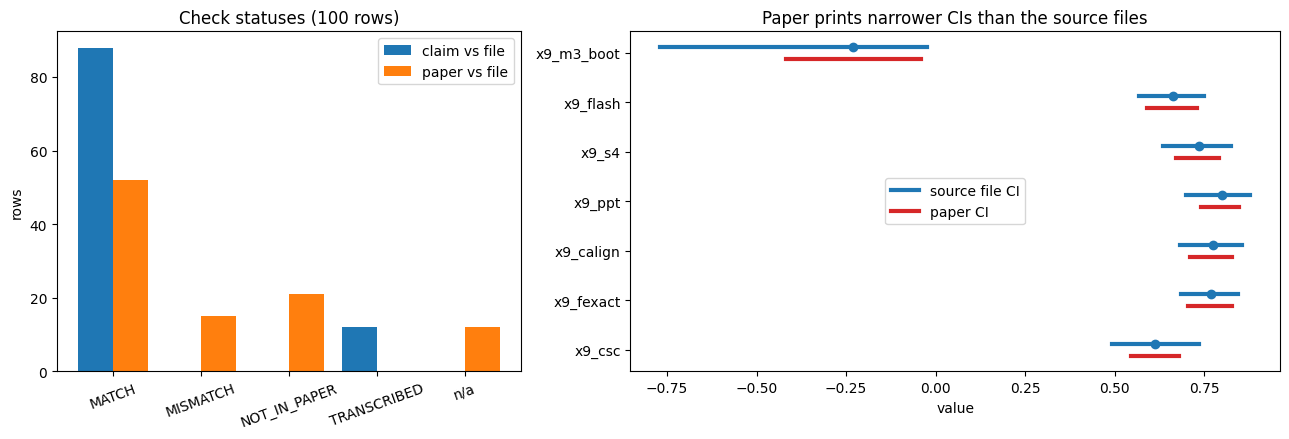

In [14]:
hyp = Counter(r["match_hyp_vs_file"] for r in rows)
pap = Counter(r["match_paper_vs_file"] for r in rows)
print("claim vs file :", dict(hyp))
print("paper vs file :", dict(pap))

print("\nPaper-vs-file MISMATCHES (paper prints X, source file says Y):")
print(f"{'claim_id':<27}{'paper value':<22}{'file value':<12}{'file CI':<20}paper line")
for r in rows:
    if r["match_paper_vs_file"] == "MISMATCH":
        print(f"{r['id']:<27}{str(r['paper_value']):<22}{str(r['source_value']):<12}{str(r['source_ci']):<20}L{r['paper_line']}")

ref = data["full_run_metrics_agg"]
print("\nDemo subset vs full original run:")
for label, demo_v, key in [
        ("claims checked", sum(1 for r in rows if r['match_hyp_vs_file'] != 'TRANSCRIBED'), "n_claims_checked"),
        ("claims MATCH their file", hyp.get("MATCH", 0), "n_match"),
        ("claim MISMATCH / NOT_FOUND", hyp.get("MISMATCH", 0) + hyp.get("NOT_FOUND", 0), "n_mismatch_hyp_vs_file"),
        ("transcribed rows", hyp.get("TRANSCRIBED", 0), "n_transcribed_rows"),
        ("paper-vs-file MATCH", pap.get("MATCH", 0), "n_match_paper_vs_file"),
        ("paper-vs-file MISMATCH", pap.get("MISMATCH", 0), "n_mismatch_paper_vs_file"),
        ("not in paper", pap.get("NOT_IN_PAPER", 0), "n_not_in_paper"),
        ("mutations caught (of 10)", mut["caught"] if RUN_MUTATION_TEST else "-", "checker_mutation_caught"),
        ("record lint failures", "not run", "lint_failures"),
        ("independent audit checks passed (of 17)", "not run", "audit_rederive_pass"),
        ("correction markers in record_final.md", "not run", "n_corrections_markers"),
        ("reviewer items CLOSED (of 11)", "not run", "reviewer_items_closed"),
        ("iter-4 spend unaccounted (USD)", "not run", "spend_iter4_unaccounted_usd")]:
    print(f"  {label:<42} demo={demo_v!s:<9} full={ref[key]:g}")

# --- plot: status counts + paper CI vs file CI for mismatched intervals
ci_rows = [r for r in rows if r["match_paper_vs_file"] == "MISMATCH" and str(r["paper_value"]).startswith("[")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
cats = ["MATCH", "MISMATCH", "NOT_IN_PAPER", "TRANSCRIBED", "n/a"]
x = range(len(cats))
axes[0].bar([i - 0.2 for i in x], [hyp.get(c, 0) for c in cats], 0.4, label="claim vs file")
axes[0].bar([i + 0.2 for i in x], [pap.get(c, 0) for c in cats], 0.4, label="paper vs file")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(cats, rotation=20)
axes[0].set_ylabel("rows"); axes[0].set_title(f"Check statuses ({len(rows)} rows)"); axes[0].legend()
for k, r in enumerate(ci_rows):
    flo, fhi = r["source_ci_raw"]
    plo, phi = (parse_literal(b)[0] for b in parse_ci(str(r["paper_value"])))
    axes[1].plot([flo, fhi], [k + 0.12] * 2, lw=3, color="tab:blue", label="source file CI" if k == 0 else None)
    axes[1].plot([plo, phi], [k - 0.12] * 2, lw=3, color="tab:red", label="paper CI" if k == 0 else None)
    axes[1].plot([r["source_value_raw"]], [k + 0.12], "o", color="tab:blue")
axes[1].set_yticks(range(len(ci_rows))); axes[1].set_yticklabels([r["id"] for r in ci_rows])
axes[1].set_xlabel("value"); axes[1].set_title("Paper prints narrower CIs than the source files"); axes[1].legend(loc="center")
plt.tight_layout(); plt.show()